2026-09-27 22:02:50,989 [INFO] Ingesting Iris dataset from remote repository...
2026-09-27 22:03:14,505 [INFO] Dataset successfully ingested. Shape: (150, 5)
2026-09-27 22:03:14,506 [INFO] Extracting dataset structural properties...

 1. DATASET STRUCTURAL METADATA & HEALTH CHECKS
Total Observations (Rows): 150
Predictor Features:        4
Feature Names:             sepal_length, sepal_width, petal_length, petal_width
Target Column Name:        species

Missing Value Audit:
  - sepal_length   : 0 missing
  - sepal_width    : 0 missing
  - petal_length   : 0 missing
  - petal_width    : 0 missing
  - species        : 0 missing

Class Balance Distribution:
  - Setosa    : 50 samples
  - Versicolor: 50 samples
  - Virginica : 50 samples
2026-09-27 22:03:14,511 [INFO] Computing global vector statistics via NumPy...

 2. GLOBAL NUMPY STATISTICAL VECTOR METRICS
               Mean  Std Dev  Min  Median  Max  IQR
sepal_length  5.843    0.828  4.3    5.80  7.9  1.3
sepal_width   3.057    0.436

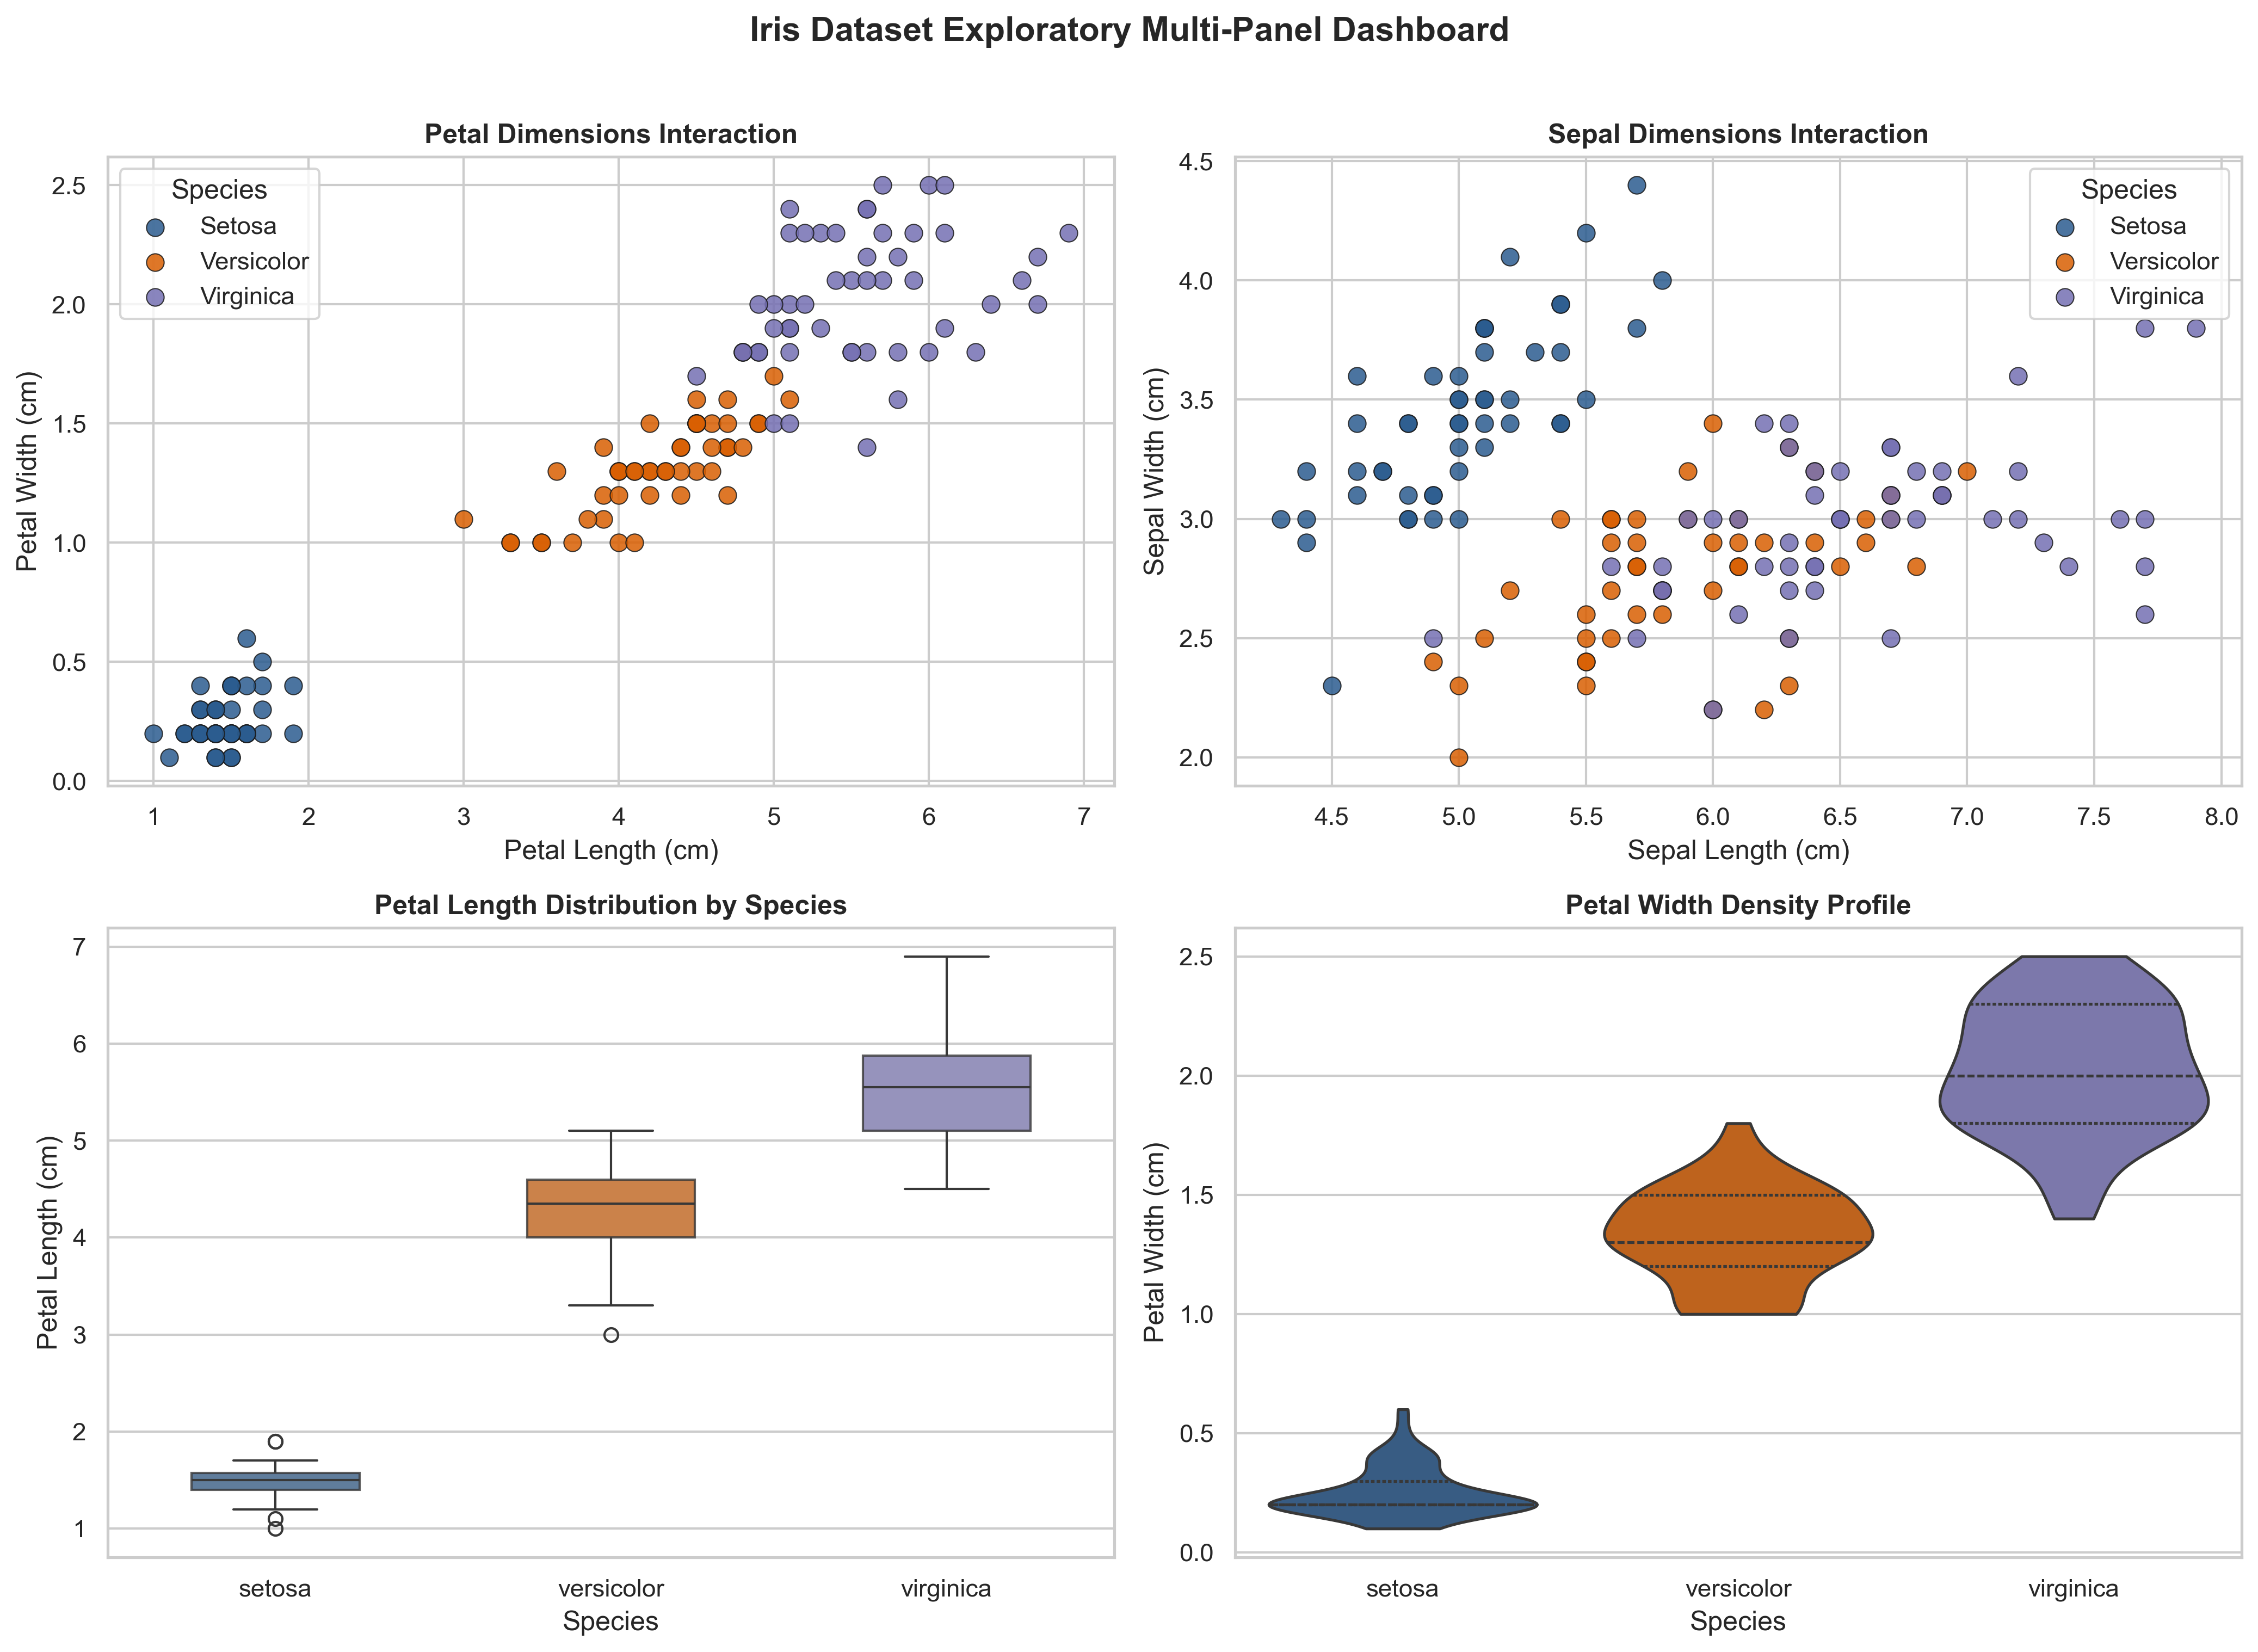

2026-09-27 22:03:18,263 [INFO] Summary dashboard saved to: iris_exploratory_summary.png
2026-09-27 22:03:18,302 [INFO] Building annotated feature pairplot matrix with correlation values...


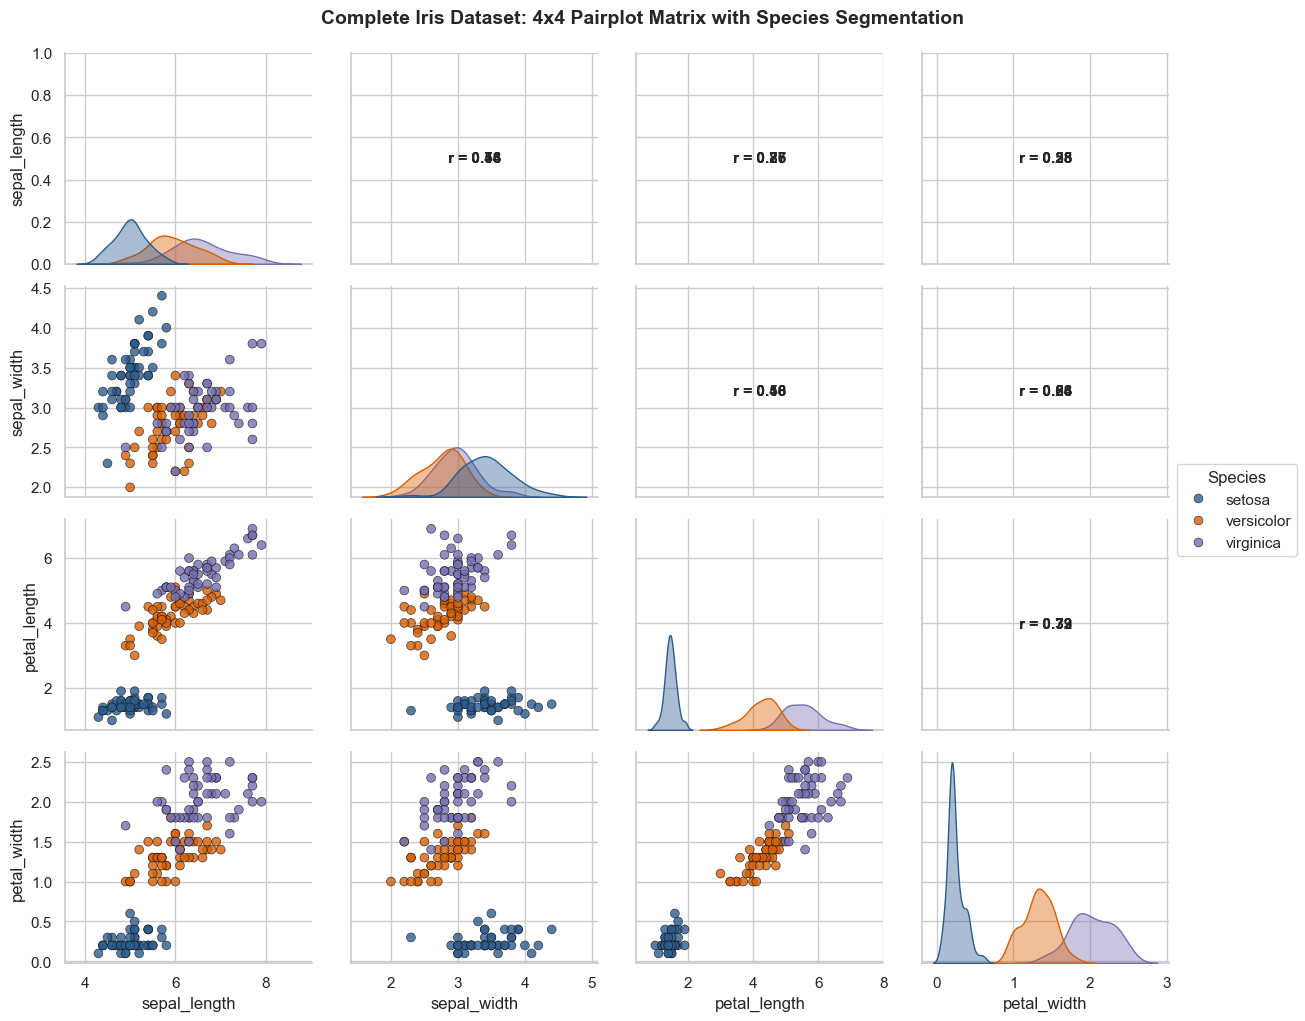

2026-09-27 22:03:22,795 [INFO] Annotated Pairplot grid saved to: iris_pairplot_matrix.png
2026-09-27 22:03:22,796 [INFO] Computing correlation matrix and generating heatmap...


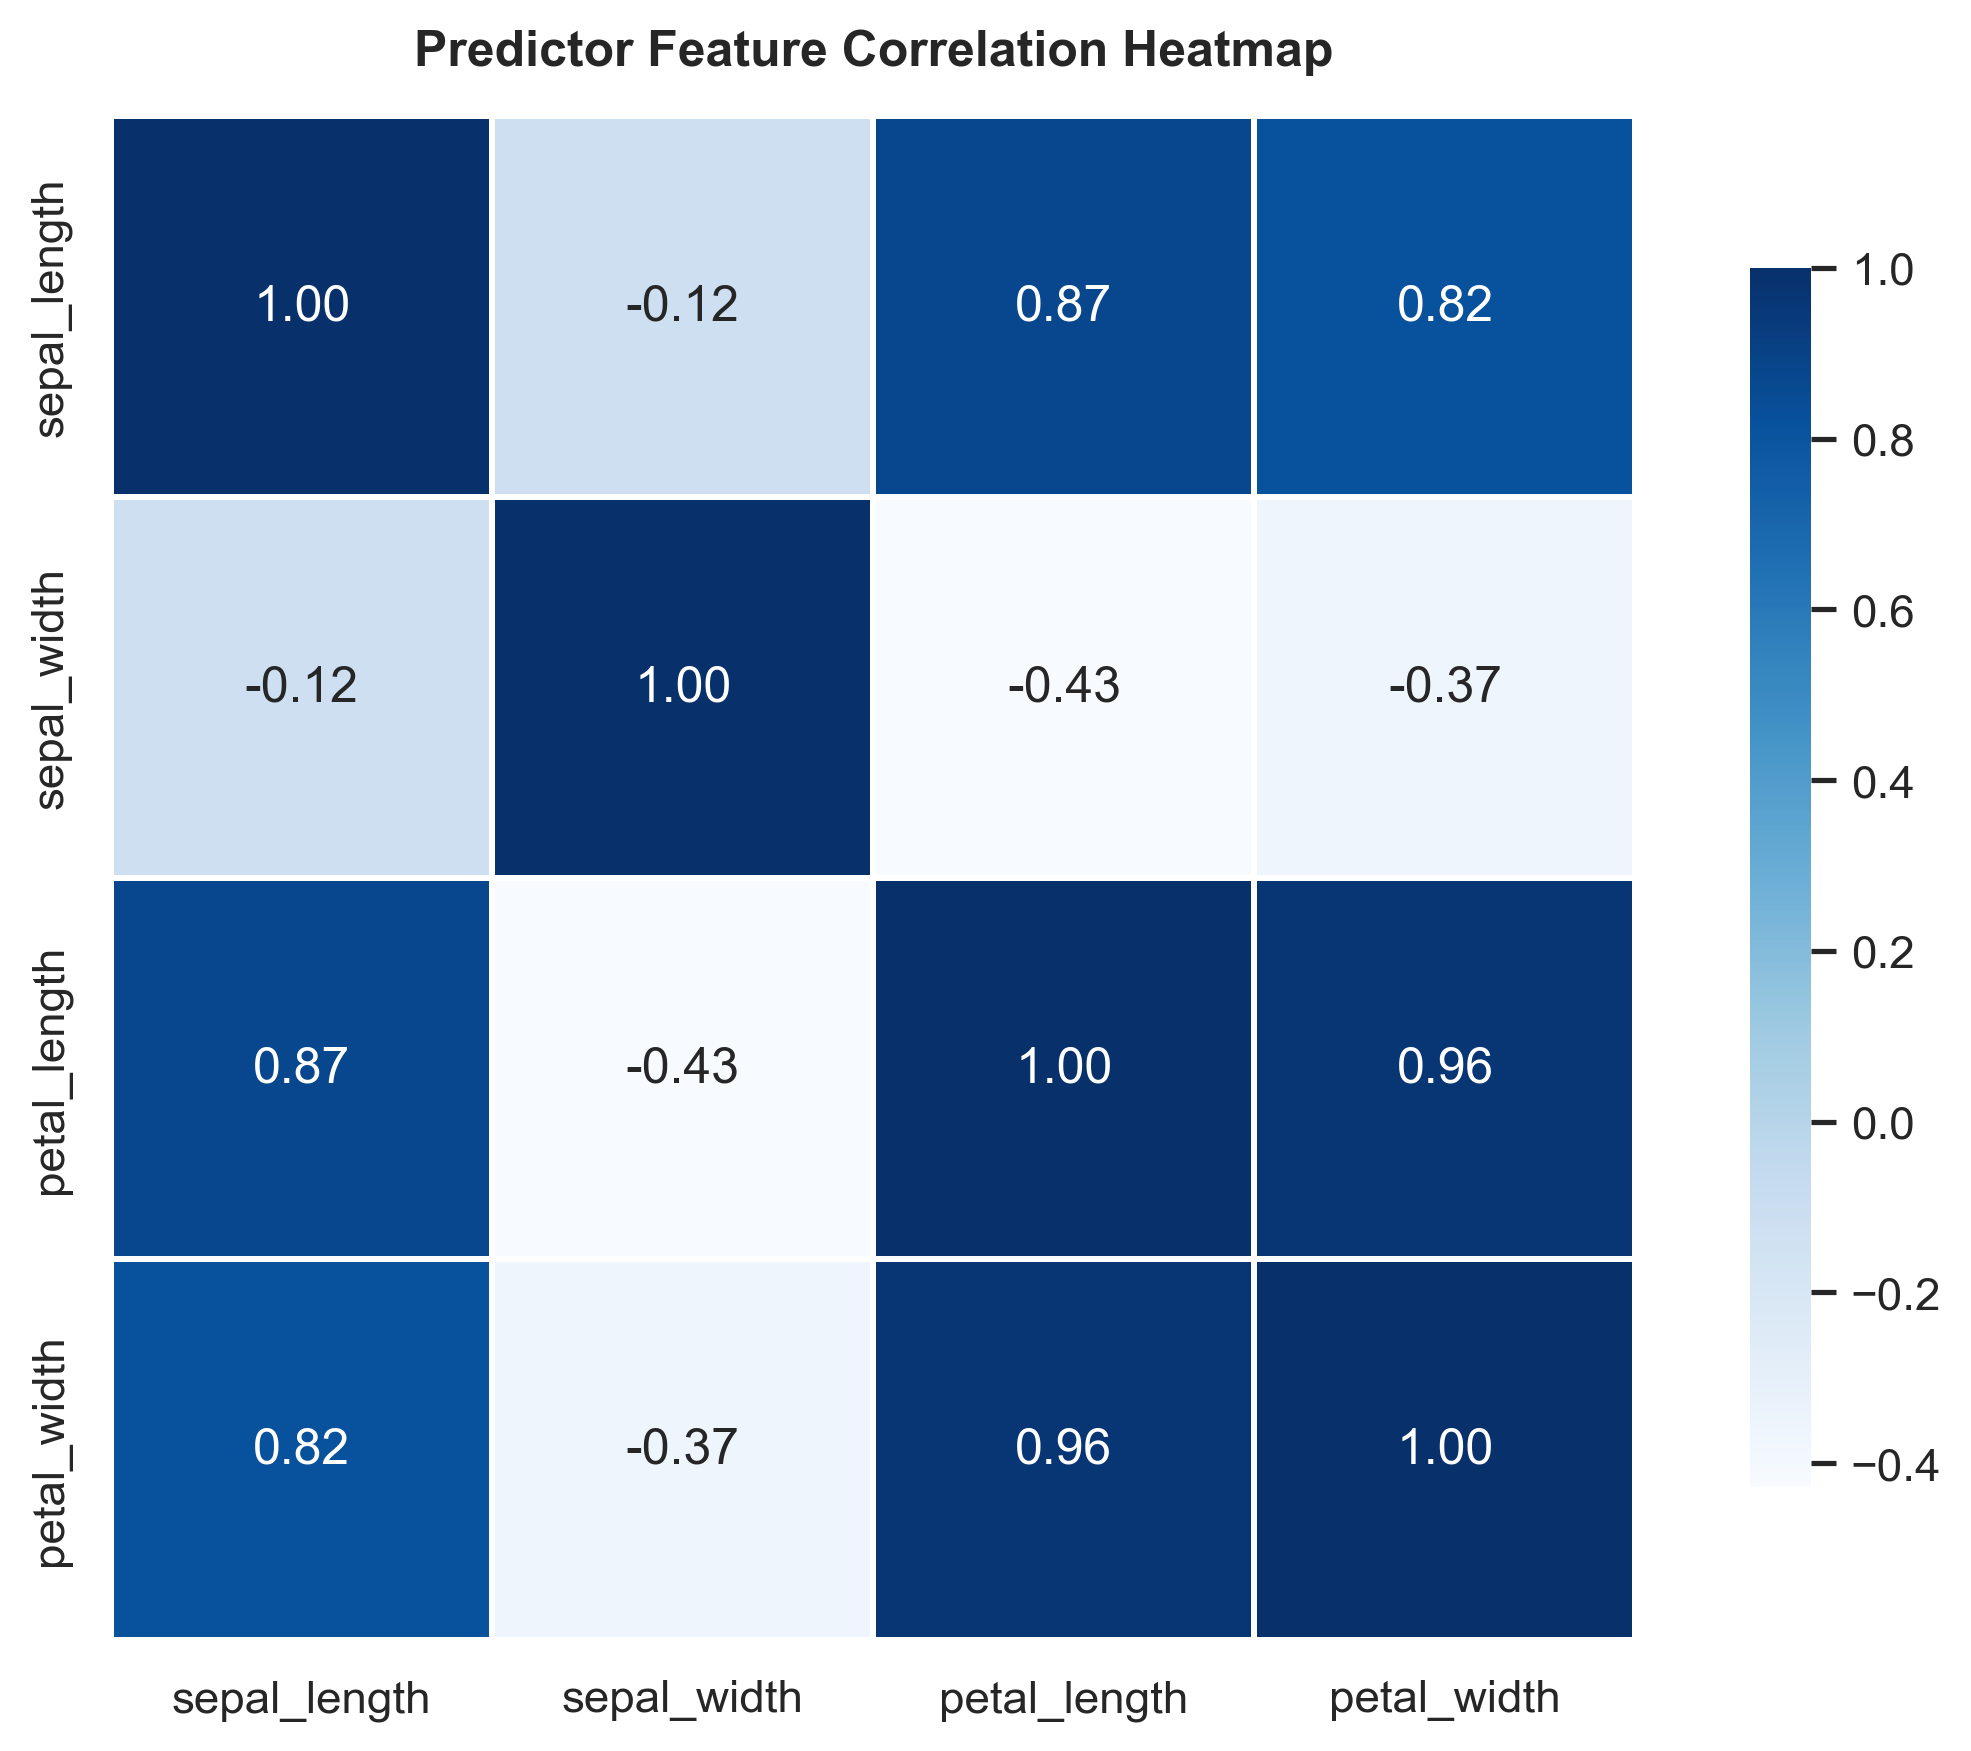

2026-09-27 22:03:23,651 [INFO] Correlation heatmap saved to: iris_correlation_heatmap.png
2026-09-27 22:03:23,652 [INFO] Performing 2D Principal Component Analysis (PCA) projection...


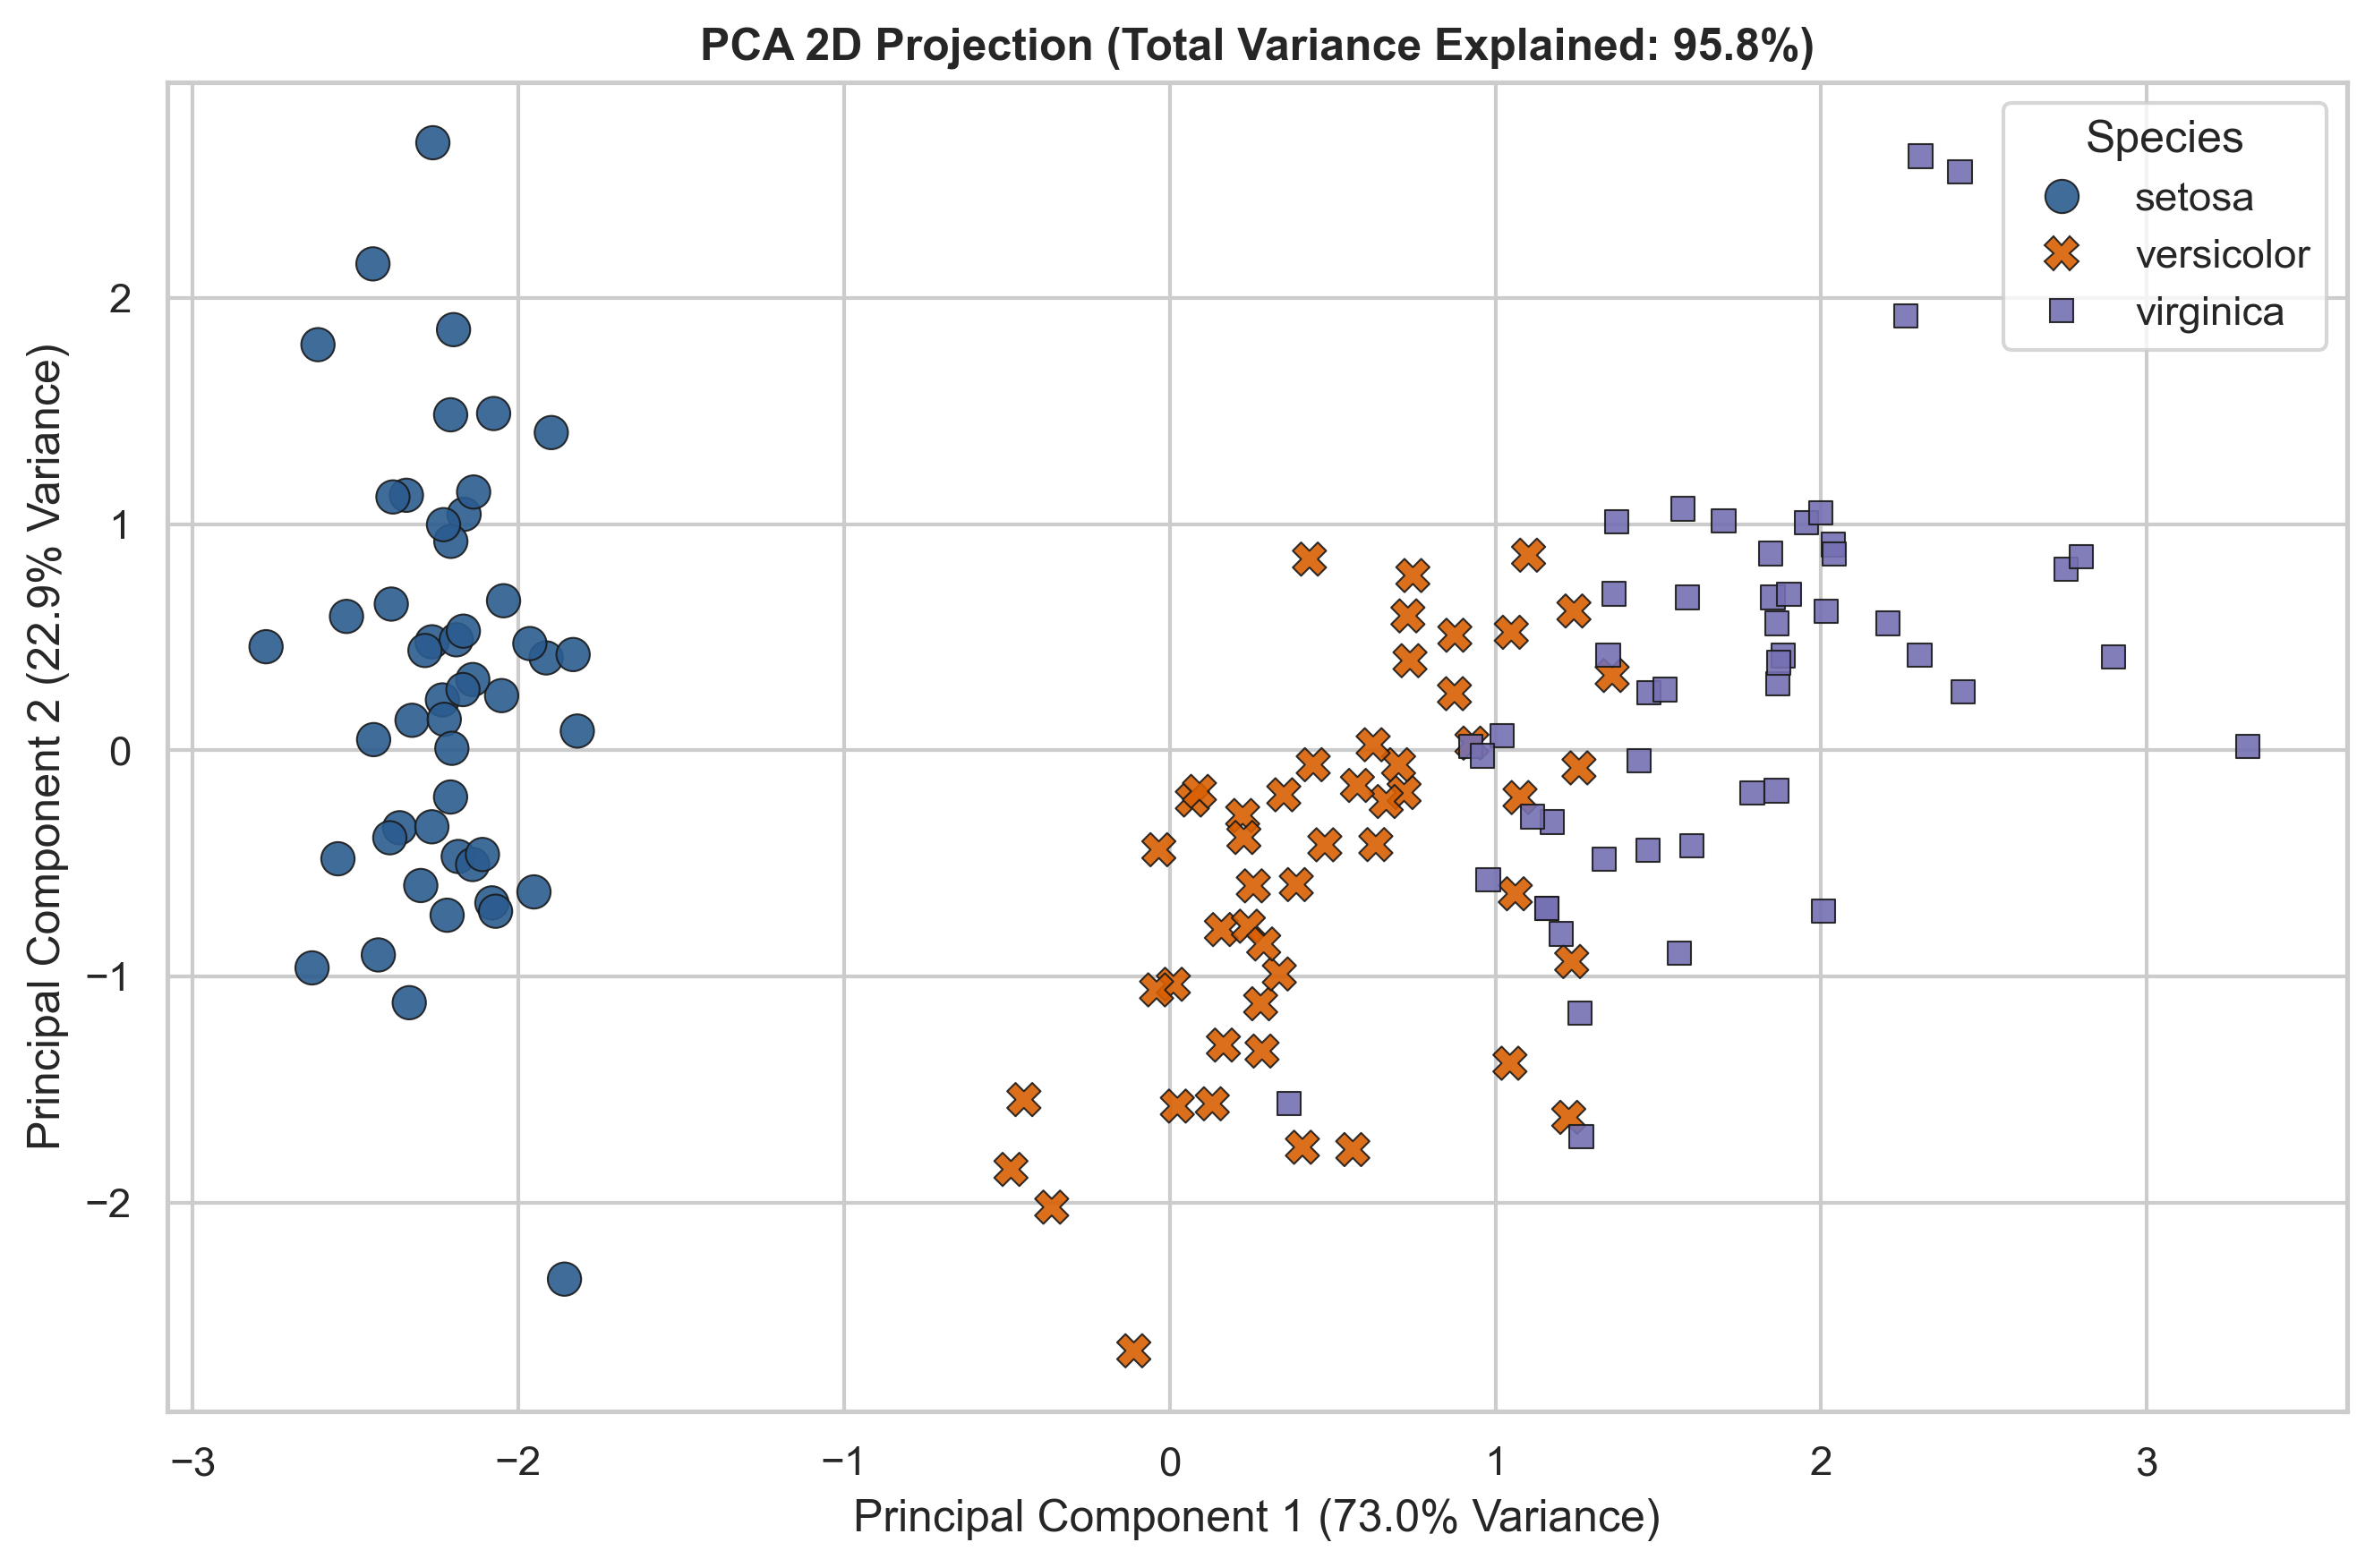

2026-09-27 22:03:24,601 [INFO] PCA 2D projection saved to: iris_pca_projection.png
2026-09-27 22:03:24,602 [INFO] Generating feature-level swarmplot distributions...


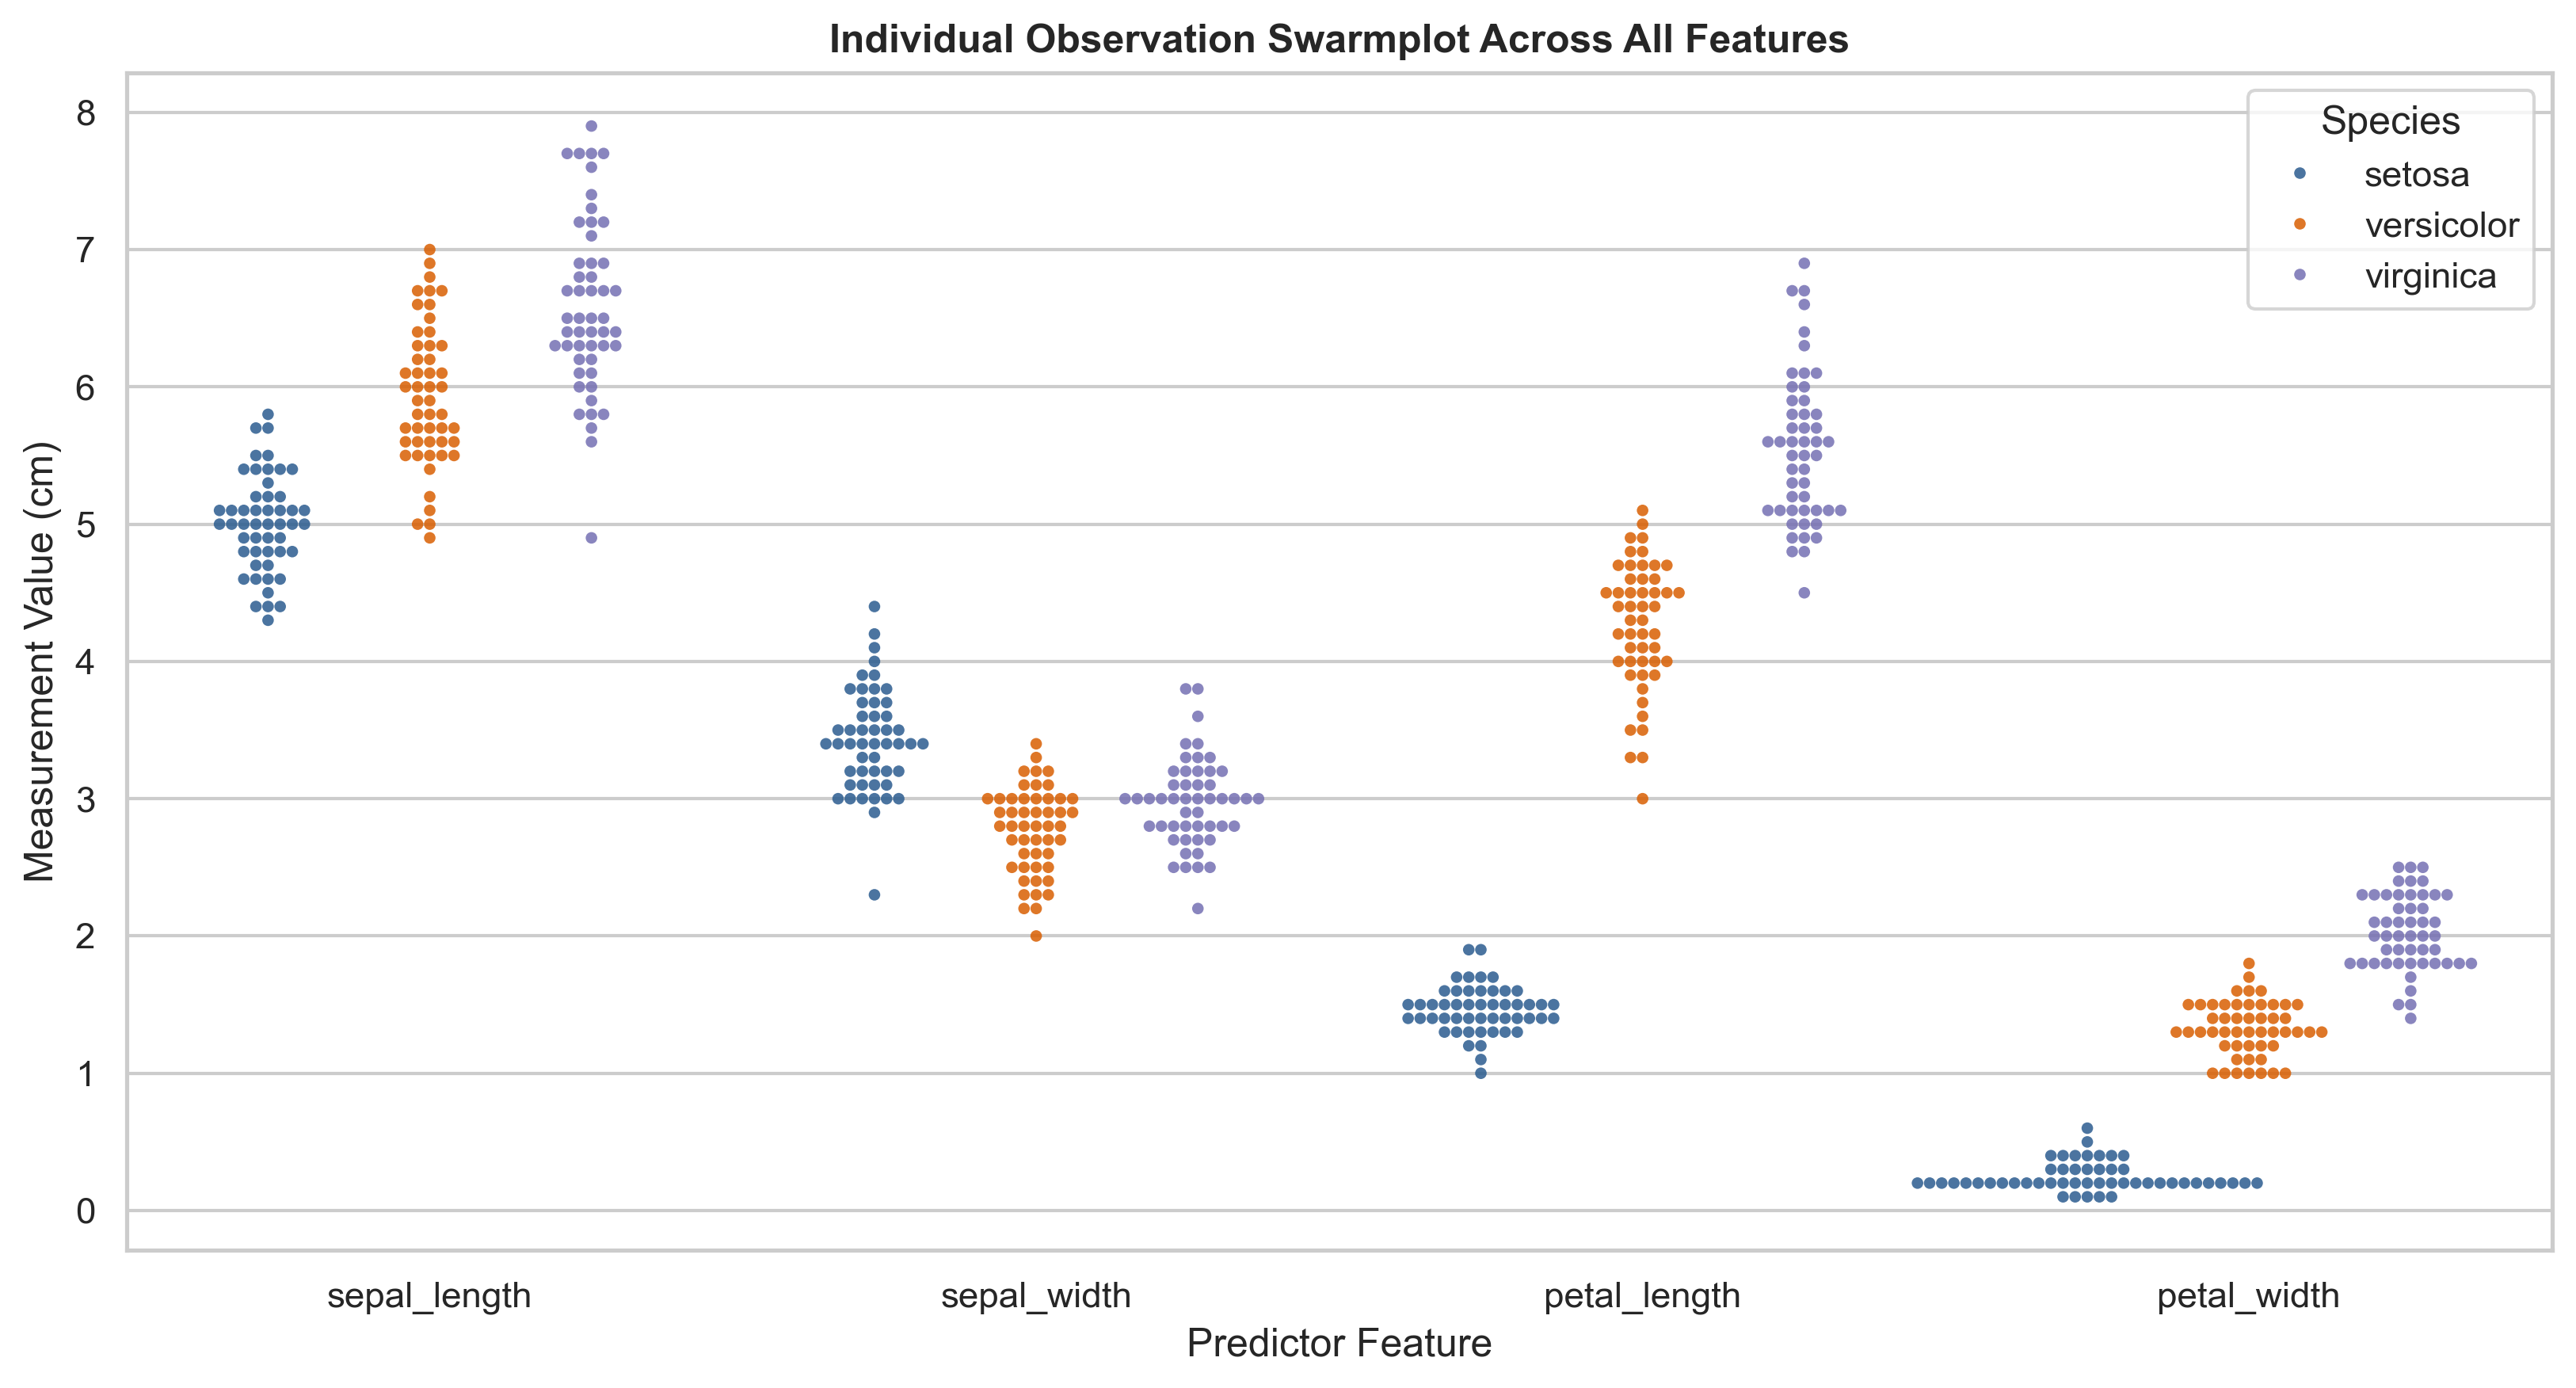

2026-09-27 22:03:26,662 [INFO] Swarmplot grid saved to: iris_swarmplot_distribution.png
2026-09-27 22:03:26,663 [INFO] Transforming dataset for Machine Learning pipeline readiness...

 5. ML PIPELINE READINESS & PREPROCESSED DATA SAMPLE
   sepal_length  sepal_width  petal_length  petal_width species  \
0           5.1          3.5           1.4          0.2  setosa   
1           4.9          3.0           1.4          0.2  setosa   
2           4.7          3.2           1.3          0.2  setosa   
3           4.6          3.1           1.5          0.2  setosa   
4           5.0          3.6           1.4          0.2  setosa   

   target_encoded  
0               0  
1               0  
2               0  
3               0  
4               0  

 6. KEY FINDINGS & FEATURE EVALUATION SUMMARY
1. Linear Separability:
   - 'Iris setosa' is strictly linearly separable using 'petal_length' (< 2.5cm).

2. Feature Importance & Correlation:
   - 'petal_length' and 'petal_width' show high l

In [6]:


from typing import Dict, Any, List
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import Image, display

# Enable runtime inline plotting for Jupyter Notebook
%matplotlib inline

# -----------------------------------------------------------------------------
# Configuration & Setup
# -----------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

# Output Image File Constants
SUMMARY_PLOT_PATH: str = "iris_exploratory_summary.png"
PAIRPLOT_PATH: str = "iris_pairplot_matrix.png"
CORR_HEATMAP_PATH: str = "iris_correlation_heatmap.png"
PCA_PLOT_PATH: str = "iris_pca_projection.png"
SWARMPLOT_PATH: str = "iris_swarmplot_distribution.png"

DATASET_URL: str = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
RANDOM_STATE: int = 42

# Set global visualization aesthetics
sns.set_theme(style="whitegrid", font_scale=1.0)
palette: Dict[str, str] = {'setosa': '#2b5c8f', 'versicolor': '#d95f02', 'virginica': '#7570b3'}


class IrisDataPipeline:
    """Encapsulates ingestion, statistical processing, EDA visualizations, PCA, and ML readiness."""

    def __init__(self, url: str = DATASET_URL) -> None:
        self.url: str = url
        self.df: pd.DataFrame = pd.DataFrame()
        self.feature_names: List[str] = []
        self.target_name: str = ""

    def load_data(self) -> pd.DataFrame:
        """Loads dataset from URL and parses target/feature columns."""
        logger.info("Ingesting Iris dataset from remote repository...")
        try:
            self.df = pd.read_csv(self.url)
            self.feature_names = list(self.df.columns[:4])
            self.target_name = str(self.df.columns[-1])
            logger.info("Dataset successfully ingested. Shape: %s", self.df.shape)
            return self.df
        except Exception as e:
            logger.error("Failed to load dataset: %s", str(e))
            raise

    def inspect_dataset(self) -> Dict[str, Any]:
        """Extracts structural metadata and health checks from the DataFrame."""
        logger.info("Extracting dataset structural properties...")
        return {
            "num_records": self.df.shape[0],
            "num_features": len(self.feature_names),
            "feature_names": self.feature_names,
            "target_variable": self.target_name,
            "missing_values": self.df.isnull().sum().to_dict(),
            "data_types": {col: str(dtype) for col, dtype in self.df.dtypes.items()},
            "class_distribution": self.df[self.target_name].value_counts().to_dict(),
        }

    def compute_numpy_statistics(self) -> pd.DataFrame:
        """Computes statistical metrics using vectorized NumPy matrix operations."""
        logger.info("Computing global vector statistics via NumPy...")
        X: np.ndarray = self.df[self.feature_names].to_numpy()

        means = np.mean(X, axis=0)
        stds = np.std(X, axis=0, ddof=1)
        mins = np.min(X, axis=0)
        medians = np.median(X, axis=0)
        maxs = np.max(X, axis=0)
        iqr = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)

        return pd.DataFrame(
            {
                "Mean": means,
                "Std Dev": stds,
                "Min": mins,
                "Median": medians,
                "Max": maxs,
                "IQR": iqr,
            },
            index=self.feature_names,
        )

    def compute_grouped_statistics(self) -> pd.DataFrame:
        """Aggregates class-segmented statistics using Pandas grouping."""
        logger.info("Aggregating group-wise statistical metrics...")
        return (
            self.df.groupby(self.target_name)
            .agg(["mean", "std", "min", "max"])
            .round(2)
        )

    # -------------------------------------------------------------------------
    # Visualizations (Configured for Runtime Notebook Display)
    # -------------------------------------------------------------------------
    def generate_summary_dashboard(self, save_path: str = SUMMARY_PLOT_PATH) -> None:
        """Generates a 2x2 multi-panel exploratory dashboard."""
        logger.info("Building summary dashboard figure...")
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
        species_list = self.df[self.target_name].unique()

        # Panel 1: Petal Length vs Petal Width Scatter
        for species in species_list:
            subset = self.df[self.df[self.target_name] == species]
            axes[0, 0].scatter(
                subset['petal_length'], subset['petal_width'],
                label=species.capitalize(), color=palette[species],
                alpha=0.85, edgecolors='k', linewidth=0.5, s=60
            )
        axes[0, 0].set_title('Petal Dimensions Interaction', fontweight='bold')
        axes[0, 0].set_xlabel('Petal Length (cm)')
        axes[0, 0].set_ylabel('Petal Width (cm)')
        axes[0, 0].legend(title="Species", frameon=True)

        # Panel 2: Sepal Length vs Sepal Width Scatter
        for species in species_list:
            subset = self.df[self.df[self.target_name] == species]
            axes[0, 1].scatter(
                subset['sepal_length'], subset['sepal_width'],
                label=species.capitalize(), color=palette[species],
                alpha=0.85, edgecolors='k', linewidth=0.5, s=60
            )
        axes[0, 1].set_title('Sepal Dimensions Interaction', fontweight='bold')
        axes[0, 1].set_xlabel('Sepal Length (cm)')
        axes[0, 1].set_ylabel('Sepal Width (cm)')
        axes[0, 1].legend(title="Species", frameon=True)

        # Panel 3: Boxplot of Petal Length by Class
        sns.boxplot(
            data=self.df, 
            x=self.target_name, 
            y='petal_length',
            hue=self.target_name,
            palette=palette, 
            ax=axes[1, 0], 
            width=0.5, 
            boxprops=dict(alpha=0.8),
            legend=False
        )
        axes[1, 0].set_title('Petal Length Distribution by Species', fontweight='bold')
        axes[1, 0].set_xlabel('Species')
        axes[1, 0].set_ylabel('Petal Length (cm)')

        # Panel 4: Violin Plot of Petal Width by Class
        sns.violinplot(
            data=self.df, 
            x=self.target_name, 
            y='petal_width',
            hue=self.target_name,
            palette=palette, 
            ax=axes[1, 1], 
            inner="quartile", 
            cut=0,
            legend=False
        )
        axes[1, 1].set_title('Petal Width Density Profile', fontweight='bold')
        axes[1, 1].set_xlabel('Species')
        axes[1, 1].set_ylabel('Petal Width (cm)')

        plt.suptitle("Iris Dataset Exploratory Multi-Panel Dashboard", fontsize=15, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight')
        plt.show() # Displays image live in cell runtime
        logger.info("Summary dashboard saved to: %s", save_path)

    def generate_seaborn_pairplot(self, save_path: str = PAIRPLOT_PATH) -> None:
        """Generates a Pairplot Matrix with KDE on diagonals, scatters below, and Pearson correlation values above."""
        logger.info("Building annotated feature pairplot matrix with correlation values...")
        
        grid = sns.PairGrid(self.df, hue=self.target_name, palette=palette, height=2.5, aspect=1.2)
        grid.map_lower(sns.scatterplot, alpha=0.8, s=40, edgecolor='k', linewidth=0.5)
        grid.map_diag(sns.kdeplot, fill=True, alpha=0.4)

        def annotate_corr(x, y, **kws):
            r, _ = pearsonr(x, y)
            ax = plt.gca()
            ax.annotate(
                f"r = {r:.2f}",
                xy=(0.5, 0.5),
                xycoords="axes fraction",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold"
            )

        grid.map_upper(annotate_corr)
        grid.add_legend(title="Species", frameon=True)
        grid.fig.suptitle("Complete Iris Dataset: 4x4 Pairplot Matrix with Species Segmentation", fontsize=14, fontweight='bold', y=1.02)
        grid.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show() # Displays image live in cell runtime
        logger.info("Annotated Pairplot grid saved to: %s", save_path)

    def generate_correlation_heatmap(self, save_path: str = CORR_HEATMAP_PATH) -> None:
        """Generates a feature correlation matrix heatmap."""
        logger.info("Computing correlation matrix and generating heatmap...")
        corr_matrix = self.df[self.feature_names].corr()

        plt.figure(figsize=(8, 6), dpi=300)
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            square=True,
            cbar_kws={"shrink": 0.8},
            linewidths=1.0,
            linecolor='white'
        )
        plt.title("Predictor Feature Correlation Heatmap", fontsize=12, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight')
        plt.show() # Displays image live in cell runtime
        logger.info("Correlation heatmap saved to: %s", save_path)

    def generate_pca_projection(self, save_path: str = PCA_PLOT_PATH) -> None:
        """Applies PCA to reduce 4D features into 2D principal components and plots projection."""
        logger.info("Performing 2D Principal Component Analysis (PCA) projection...")
        X = self.df[self.feature_names].values
        
        X_scaled = StandardScaler().fit_transform(X)
        
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        X_pca = pca.fit_transform(X_scaled)
        var_ratio = pca.explained_variance_ratio_

        pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
        pca_df['species'] = self.df[self.target_name]

        plt.figure(figsize=(9, 6), dpi=300)
        sns.scatterplot(
            data=pca_df,
            x='PC1', y='PC2',
            hue='species',
            palette=palette,
            style='species',
            s=80, alpha=0.9, edgecolor='k', linewidth=0.5
        )
        plt.title(
            f"PCA 2D Projection (Total Variance Explained: {sum(var_ratio)*100:.1f}%)",
            fontsize=12, fontweight='bold'
        )
        plt.xlabel(f"Principal Component 1 ({var_ratio[0]*100:.1f}% Variance)")
        plt.ylabel(f"Principal Component 2 ({var_ratio[1]*100:.1f}% Variance)")
        plt.legend(title="Species", frameon=True)
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight')
        plt.show() # Displays image live in cell runtime
        logger.info("PCA 2D projection saved to: %s", save_path)

    def generate_swarmplot_grid(self, save_path: str = SWARMPLOT_PATH) -> None:
        """Generates a melted swarmplot grid showing individual observations per feature."""
        logger.info("Generating feature-level swarmplot distributions...")
        
        df_melted = pd.melt(
            self.df,
            id_vars=[self.target_name],
            value_vars=self.feature_names,
            var_name='Feature',
            value_name='Measurement (cm)'
        )

        plt.figure(figsize=(11, 6), dpi=300)
        sns.swarmplot(
            data=df_melted,
            x='Feature',
            y='Measurement (cm)',
            hue=self.target_name,
            palette=palette,
            dodge=True,
            size=3.5,
            alpha=0.85
        )
        plt.title("Individual Observation Swarmplot Across All Features", fontsize=12, fontweight='bold')
        plt.xlabel("Predictor Feature")
        plt.ylabel("Measurement Value (cm)")
        plt.legend(title="Species", frameon=True)
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight')
        plt.show() # Displays image live in cell runtime
        logger.info("Swarmplot grid saved to: %s", save_path)

    # -------------------------------------------------------------------------
    # Machine Learning Data Preparation
    # -------------------------------------------------------------------------
    def prepare_ml_dataset(self) -> pd.DataFrame:
        """Prepares a clean copy of the dataset formatted for ML model ingestion."""
        logger.info("Transforming dataset for Machine Learning pipeline readiness...")
        ml_df = self.df.copy()
        target_map = {species: idx for idx, species in enumerate(ml_df[self.target_name].unique())}
        ml_df['target_encoded'] = ml_df[self.target_name].map(target_map)
        return ml_df


def main() -> None:
    """Execution driver for the pipeline."""
    pipeline = IrisDataPipeline()

    # 1. Ingestion
    pipeline.load_data()

    # 2. Structural Inspection
    info = pipeline.inspect_dataset()
    print("\n" + "=" * 65)
    print(" 1. DATASET STRUCTURAL METADATA & HEALTH CHECKS")
    print("=" * 65)
    print(f"Total Observations (Rows): {info['num_records']}")
    print(f"Predictor Features:        {info['num_features']}")
    print(f"Feature Names:             {', '.join(info['feature_names'])}")
    print(f"Target Column Name:        {info['target_variable']}")
    print("\nMissing Value Audit:")
    for col, missing_count in info['missing_values'].items():
        print(f"  - {col:15s}: {missing_count} missing")

    print("\nClass Balance Distribution:")
    for cls, count in info['class_distribution'].items():
        print(f"  - {cls.capitalize():10s}: {count} samples")

    # 3. Vector Statistics
    global_stats = pipeline.compute_numpy_statistics()
    print("\n" + "=" * 65)
    print(" 2. GLOBAL NUMPY STATISTICAL VECTOR METRICS")
    print("=" * 65)
    print(global_stats.round(3).to_string())

    # 4. Segmented Class Aggregations
    grouped_stats = pipeline.compute_grouped_statistics()
    print("\n" + "=" * 65)
    print(" 3. CLASS-SEGMENTED FEATURE AGGREGATIONS (PANDAS)")
    print("=" * 65)
    print(grouped_stats.to_string())

    # 5. Visualizations (Generated and rendered directly in Notebook cell output)
    print("\n" + "=" * 65)
    print(" 4. GENERATING RUNTIME VISUALIZATIONS")
    print("=" * 65)
    pipeline.generate_summary_dashboard()
    pipeline.generate_seaborn_pairplot()
    pipeline.generate_correlation_heatmap()
    pipeline.generate_pca_projection()
    pipeline.generate_swarmplot_grid()

    # 6. ML Preparation
    ml_data = pipeline.prepare_ml_dataset()
    print("\n" + "=" * 65)
    print(" 5. ML PIPELINE READINESS & PREPROCESSED DATA SAMPLE")
    print("=" * 65)
    print(ml_data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species', 'target_encoded']].head())

    print("\n" + "=" * 65)
    print(" 6. KEY FINDINGS & FEATURE EVALUATION SUMMARY")
    print("=" * 65)
    print("1. Linear Separability:")
    print("   - 'Iris setosa' is strictly linearly separable using 'petal_length' (< 2.5cm).")
    print("\n2. Feature Importance & Correlation:")
    print("   - 'petal_length' and 'petal_width' show high linear correlation (r > 0.95).")
    print("   - These two features provide optimal decision boundaries for ML algorithms.")
    print("=" * 65 + "\n")


if __name__ == "__main__":
    main()